# Predicting heart disease using machine learning

This notebook looks into using various Python-based machine learning and data science libraries in an attempt to build a machine learning model capable of predicting whether or not someone has heart disease based on their medical attributes.

We're going to take the following approach:
1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem Definition

In a statement,
> Given clinical parameters about a patient, can we predict whether or not they have heart disease?

## 2. Data

There is also a version of it available on Kaggle. https://www.kaggle.com/datasets/sumaiyatasmeem/heart-disease-classification-dataset

## 3. Evaluation

> If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we'll pursue the project.

## 4. Features

This is where you'll get different information about each of the features in your data. You can do this via doing your own research (such as looking at the links above) or by talking to a subject matter expert (someone who knows about the dataset).

**Create data dictionary**

1. age - age in years
2. sex - (1 = male; 0 = female)
3. cp - chest pain type
    * 0: Typical angina: chest pain related decrease blood supply to the heart
    * 1: Atypical angina: chest pain not related to heart
    * 2: Non-anginal pain: typically esophageal spasms (non heart related)
    * 3: Asymptomatic: chest pain not showing signs of disease
4. trestbps - resting blood pressure (in mm Hg on admission to the hospital) anything above 130-140 is typically cause for concern
5. chol - serum cholestoral in mg/dl
    * serum = LDL + HDL + .2 * triglycerides
    * above 200 is cause for concern
6. fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
    * '>126' mg/dL signals diabetes
7. restecg - resting electrocardiographic results
    * 0: Nothing to note
    * 1: ST-T Wave abnormality
        * can range from mild symptoms to severe problems
        * signals non-normal heart beat
    * 2: Possible or definite left ventricular hypertrophy
        * Enlarged heart's main pumping chamber
8. thalach - maximum heart rate achieved
9. exang - exercise induced angina (1 = yes; 0 = no)
10. oldpeak - ST depression induced by exercise relative to rest looks at stress of heart during excercise unhealthy heart will stress more
11. slope - the slope of the peak exercise ST segment
    * 0: Upsloping: better heart rate with excercise (uncommon)
    * 1: Flatsloping: minimal change (typical healthy heart)
    * 2: Downslopins: signs of unhealthy heart
12. ca - number of major vessels (0-3) colored by flourosopy
    * colored vessel means the doctor can see the blood passing through
    * the more blood movement the better (no clots)
13. thal - thalium stress result
    * 1,3: normal
    * 6: fixed defect: used to be defect but ok now
    * 7: reversable defect: no proper blood movement when excercising
14. target - have disease or not (1=yes, 0=no) (= the predicted attribute)

## Preparing the tools

We're going to use pandas, Matplotlib and NumPy for data analysis and manipulation.

In [95]:
# import all the tools we need

# Regular EDA and plotting libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline
# we want to see our plots inline

# models from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation libraries
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay



## Load the data 

In [126]:
df = pd.read_csv("heart disease classification dataset.csv")
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()
df.shape

(303, 14)

## Data Exploration (Exploratory data analysis or EDA)

The goal here is to find out more about the data and become a subject matter export on the dataset you working with.

1. What questions are you trying to solve ?
2. What kind of data do we have and how do we treat different types?
3. What is missing from the dta and how do you deal with it?
4. Where are the outliers and why should you cate about them?
5. How can you add, change or remove features to get out you data?

In [127]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [128]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,female,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,no
299,45,male,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,no
300,68,male,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,no
301,57,male,0,NaN,131.0,0,1,115.0,1,1.2,1,1,3,no
302,57,female,1,130.0,236.0,0,0,174.0,0,0.0,1,1,2,no


In [129]:
df["target"].value_counts()

target
yes    165
no     138
Name: count, dtype: int64

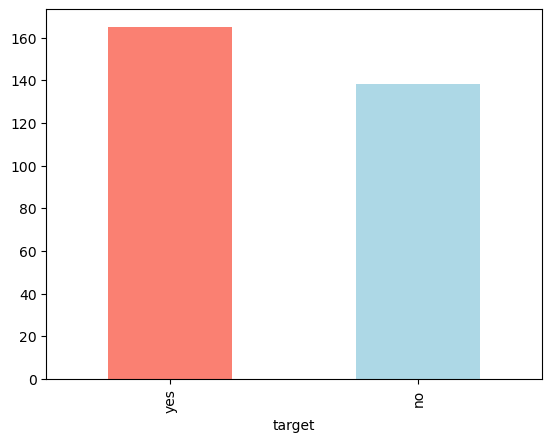

In [130]:
df["target"].value_counts().plot(kind="bar", color=["salmon", "lightblue"]);

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    object 
 2   cp        303 non-null    int64  
 3   trestbps  299 non-null    float64
 4   chol      302 non-null    float64
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   298 non-null    float64
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    object 
dtypes: float64(4), int64(8), object(2)
memory usage: 33.3+ KB


In [132]:
df["trestbps"].fillna(df["trestbps"].mean(), inplace=True)
df["chol"].fillna(df["chol"].median(), inplace=True)
df["thalach"].fillna(df["thalach"].mean(), inplace=True)

C:\Users\MR.CRIMINAL\AppData\Local\Temp\ipykernel_6956\2944301666.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["trestbps"].fillna(df["trestbps"].mean(), inplace=True)
C:\Users\MR.CRIMINAL\AppData\Local\Temp\ipykernel_6956\2944301666.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [133]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [134]:
df.describe()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.966997,131.712375,246.298680,0.148515,0.528053,149.865772,0.326733,1.039604,1.399340,0.729373,2.313531
std,9.082101,1.032052,17.511894,51.823351,0.356198,0.525860,22.376122,0.469794,1.161075,0.616226,1.022606,0.612277
min,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,120.000000,211.000000,0.000000,0.000000,136.000000,0.000000,0.000000,1.000000,0.000000,2.000000
50%,55.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000
75%,61.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000
max,77.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000


In [135]:

# Step 1: Convert 'target' to numeric if it's still 'yes'/'no'
if df["target"].dtype == "object":
    df["target"] = df["target"].map({"yes": 1, "no": 0})

if df["sex"].dtype == "object":
    df["sex"] = df["sex"].map({"male": 1, "female": 0})

# Step 2: Handle missing values in numeric columns using mean
for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col] = df[col].fillna(df[col].mean())

# Step 3: Fill missing values in categorical columns with "missing"
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna("missing")

# Step 4: One-hot encode categorical features (like 'sex', 'thal', etc.)
X = pd.get_dummies(df.drop("target", axis=1), drop_first=True)

# Step 5: Define target column
y = df["target"]

# Step 6: Final check for NaN values (optional safety)
assert X.isnull().sum().sum() == 0, "There are still NaNs in X"
assert y.isnull().sum() == 0, "There are still NaNs in y"

# Now you can safely split and use this in models
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Your data is ready for modeling now
print("✅ Data cleaned, encoded, and ready for ML.")

✅ Data cleaned, encoded, and ready for ML.


### Heart Disease frequescy according to sex

In [136]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [137]:
  # Compate target column with sex column
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


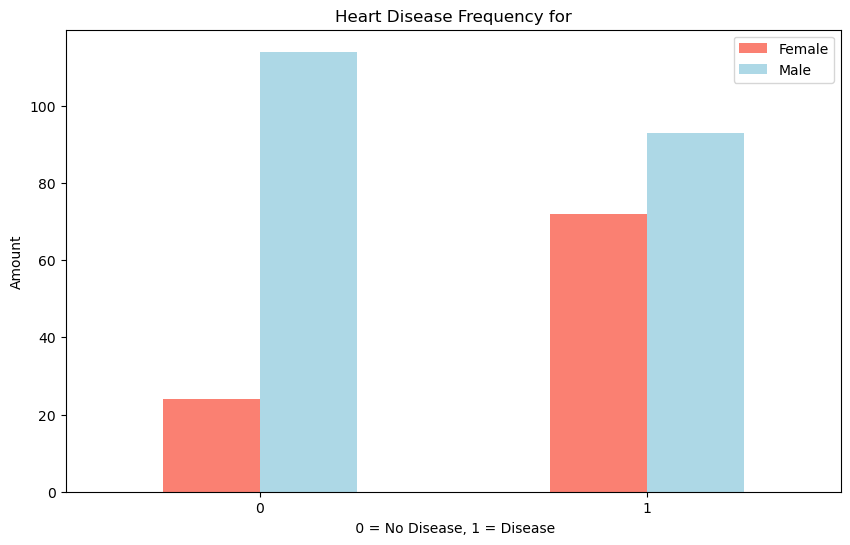

In [138]:
 # Create a plot of crosstab
pd.crosstab(df.target, df.sex).plot(kind="bar", figsize = (10,6),
                                    color=["salmon", "lightblue"])

plt.title("Heart Disease Frequency for")
plt.xlabel(" 0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"]);
plt.xticks(rotation=0);

### Age vs. Max Heart Rate for Heart Disease

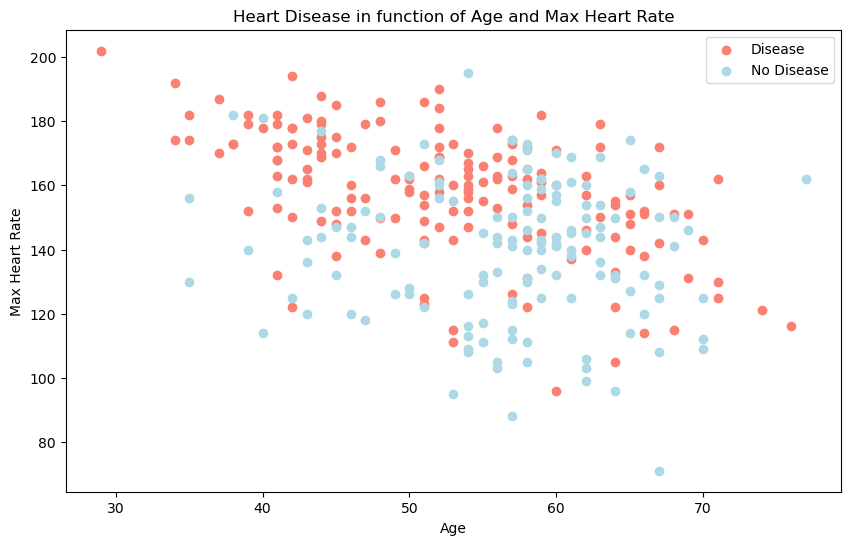

In [139]:
# Create another figure
plt.figure(figsize=(10, 6))

# Scatter with postivie examples
plt.scatter(df.age[df.target==1],
            df.thalach[df.target==1],
            c="salmon")

# Scatter with negative examples
plt.scatter(df.age[df.target==0],
            df.thalach[df.target==0],
            c="lightblue")

# Add some helpful info
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"]);

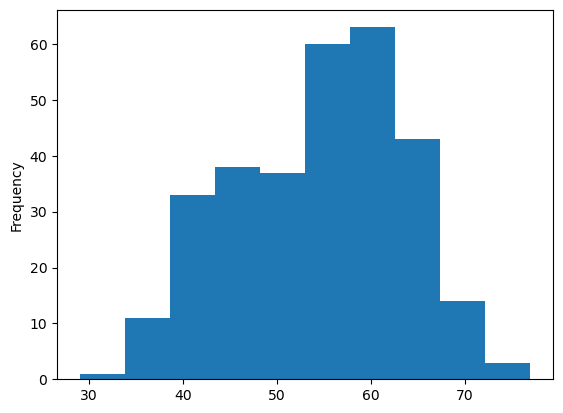

In [140]:
# check the distribution of the age column with a histogram
df.age.plot.hist();

### Heart Disease Frequency per Chest Pain Type

3. cp - chest pain type
    * 0: Typical angina: chest pain related decrease blood supply to the heart
    * 1: Atypical angina: chest pain not related to heart
    * 2: Non-anginal pain: typically esophageal spasms (non heart related)
    * 3: Asymptomatic: chest pain not showing signs of disease

In [141]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


In [142]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145.000000,233.0,1,0,150.0,0,2.3,0,0,1,1
1,37,1,2,130.000000,250.0,0,1,187.0,0,3.5,0,0,2,1
2,41,0,1,130.000000,204.0,0,0,172.0,0,1.4,2,0,2,1
3,56,1,1,120.000000,236.0,0,1,178.0,0,0.8,2,0,2,1
4,57,0,0,131.712375,354.0,0,1,163.0,1,0.6,2,0,2,1


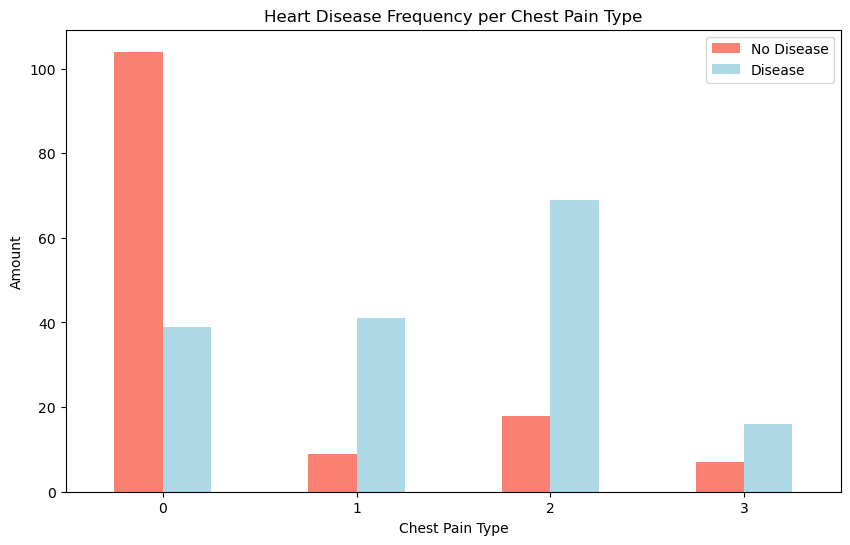

In [143]:
# Make the crosstabe more visual
pd.crosstab(df.cp, df.target).plot(kind="bar",
                                   figsize=(10, 6),
                                   color = ["salmon", "lightblue"])

# add some communcation
plt.title("Heart Disease Frequency per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0);

In [144]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145.000000,233.0,1,0,150.0,0,2.3,0,0,1,1
1,37,1,2,130.000000,250.0,0,1,187.0,0,3.5,0,0,2,1
2,41,0,1,130.000000,204.0,0,0,172.0,0,1.4,2,0,2,1
3,56,1,1,120.000000,236.0,0,1,178.0,0,0.8,2,0,2,1
4,57,0,0,131.712375,354.0,0,1,163.0,1,0.6,2,0,2,1


In [145]:
# Make a correlation matrix
df.corr(numeric_only=True)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279321,0.213534,0.121308,-0.116211,-0.394370,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.063602,-0.197484,0.045032,-0.058196,-0.051004,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047841,-0.077544,0.094444,0.044421,0.299178,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279321,-0.063602,0.047841,1.000000,0.125401,0.175680,-0.110333,-0.029408,0.069590,0.193631,-0.120827,0.098237,0.060232,-0.141162
chol,0.213534,-0.197484,-0.077544,0.125401,1.000000,0.013016,-0.150460,-0.022898,0.066566,0.053359,-0.003384,0.070699,0.098474,-0.085984
fbs,0.121308,0.045032,0.094444,0.175680,0.013016,1.000000,-0.084189,0.001567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.110333,-0.150460,-0.084189,1.000000,0.037129,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.394370,-0.051004,0.299178,-0.029408,-0.022898,0.001567,0.037129,1.000000,-0.394595,-0.345398,0.378425,-0.207516,-0.105437,0.409645
exang,0.096801,0.141664,-0.394280,0.069590,0.066566,0.025665,-0.070733,-0.394595,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193631,0.053359,0.005747,-0.058770,-0.345398,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


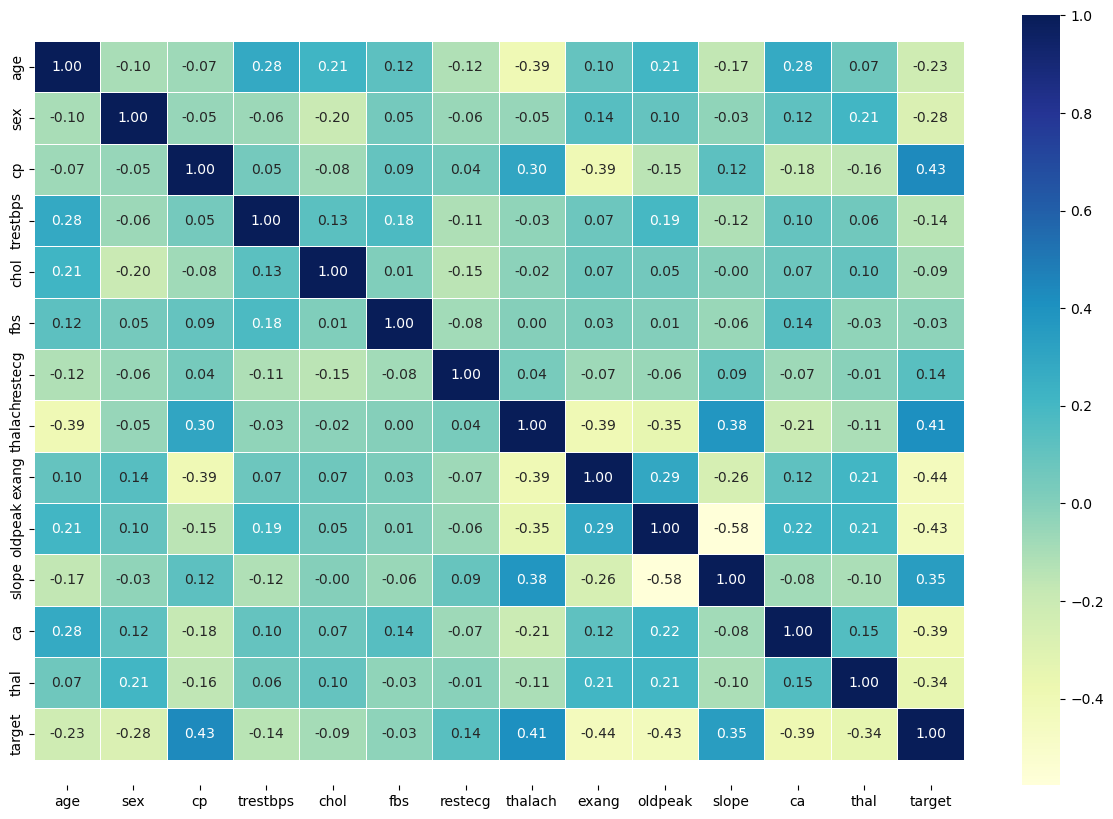

In [146]:
# lets make our correlation matrix a little prettier
corr_matrix = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidths=0.5,
                 fmt=".2f",
                 cmap="YlGnBu");

bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5);

## Modeling

In [147]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145.000000,233.0,1,0,150.0,0,2.3,0,0,1,1
1,37,1,2,130.000000,250.0,0,1,187.0,0,3.5,0,0,2,1
2,41,0,1,130.000000,204.0,0,0,172.0,0,1.4,2,0,2,1
3,56,1,1,120.000000,236.0,0,1,178.0,0,0.8,2,0,2,1
4,57,0,0,131.712375,354.0,0,1,163.0,1,0.6,2,0,2,1


In [148]:
# Split the data into X and y
X =df.drop("target", axis =1)

y = df["target"]

In [149]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145.000000,233.0,1,0,150.0,0,2.3,0,0,1
1,37,1,2,130.000000,250.0,0,1,187.0,0,3.5,0,0,2
2,41,0,1,130.000000,204.0,0,0,172.0,0,1.4,2,0,2
3,56,1,1,120.000000,236.0,0,1,178.0,0,0.8,2,0,2
4,57,0,0,131.712375,354.0,0,1,163.0,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140.000000,241.0,0,1,123.0,1,0.2,1,0,3
299,45,1,3,110.000000,264.0,0,1,132.0,0,1.2,1,0,3
300,68,1,0,144.000000,193.0,1,1,141.0,0,3.4,1,2,3
301,57,1,0,131.712375,131.0,0,1,115.0,1,1.2,1,1,3


In [150]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [151]:
# Split the data into train and test sets
np.random.seed(42)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [152]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145.000000,233.0,1,0,150.0,0,2.3,0,0,1
1,37,1,2,130.000000,250.0,0,1,187.0,0,3.5,0,0,2
2,41,0,1,130.000000,204.0,0,0,172.0,0,1.4,2,0,2
3,56,1,1,120.000000,236.0,0,1,178.0,0,0.8,2,0,2
4,57,0,0,131.712375,354.0,0,1,163.0,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140.000000,241.0,0,1,123.0,1,0.2,1,0,3
299,45,1,3,110.000000,264.0,0,1,132.0,0,1.2,1,0,3
300,68,1,0,144.000000,193.0,1,1,141.0,0,3.4,1,2,3
301,57,1,0,131.712375,131.0,0,1,115.0,1,1.2,1,1,3


In [153]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120.0,295.0,0,1,162.0,0,0.0,2,0,2
202,58,1,0,150.0,270.0,0,0,111.0,1,0.8,2,0,3
196,46,1,2,150.0,231.0,0,1,147.0,0,3.6,1,0,2
75,55,0,1,135.0,250.0,0,0,161.0,0,1.4,1,0,2
176,60,1,0,117.0,230.0,1,1,160.0,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140.0,233.0,0,1,163.0,0,0.6,1,1,3
71,51,1,2,94.0,227.0,0,1,154.0,1,0.0,2,1,3
106,69,1,3,160.0,234.0,1,0,131.0,0,0.1,1,1,2
270,46,1,0,120.0,249.0,0,0,144.0,0,0.8,2,0,3


In [154]:
y_train, len(y_train)

(132    1
 202    0
 196    0
 75     1
 176    0
       ..
 188    0
 71     1
 106    1
 270    0
 102    1
 Name: target, Length: 242, dtype: int64,
 242)

Now we've got our data split into training and test sets, it's time to build a machine learning model.

We'll train it (find the patterns) on the training set.

And we'll test it (use the patterns) on the test set.

We're going to try 3 different machine learning models:
1. Logistic Regression 
2. K-Nearest Neighbours Classifier
3. Random Forest Classifier

In [155]:
# Put models in a dictionary
models = {"Logistic Regression": LogisticRegression(max_iter=1000),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier()}

# Create a function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models: a dictionary of different Scikit-Learn machine learning models
    X_train: training data (features)
    X_test: testing data (features)
    y_train: training labels
    y_test: testing labels
    """
    np.random.seed(42)

    # Make a dictionary to keep model scores
    model_scores = {}

    # Loop through models
    for name, model in models.items():
        # Fit the model to the data 
        model.fit(X_train, y_train)

        # Evaluate the model and append its score to model_Scores
        model_scores[name] = model.score(X_test, y_test)

    return model_scores



In [157]:
model_Score = fit_and_score(models = models,
                            X_train = X_train,
                            X_test = X_test,
                            y_train = y_train,
                            y_test = y_test)
                
model_Score

c:\Users\MR.CRIMINAL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.8524590163934426,
 'KNN': 0.639344262295082,
 'Random Forest': 0.8524590163934426}

## Model Comparison

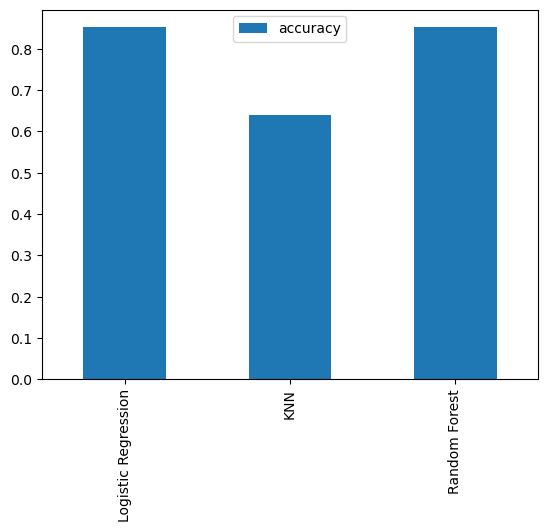

In [159]:
model_compare = pd.DataFrame(model_Score, index=["accuracy"])
model_compare.T.plot.bar();

Now we've got a baseline model... and we know a model's first predictions aren't always what we should based our next steps off. What should we do?

Let's look at the following:
* Hypyterparameter tuning
* Feature importance
* Confusion matrix
* Cross-validation
* Precision
* Recall
* F1 score
* Classification report
* ROC curve
* Area under the curve (AUC)

### Hyperparameter tuning (by hand)

In [161]:
# Let's tune for KNN

train_scores = []
test_scores = []

#create a list of different values for n_nighbors
neighbors = range(1,21)

# setup KNN instance
knn = KNeighborsClassifier()

# loop through different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)

    # fit the algorithm
    knn.fit(X_train, y_train)

    # Update the training scores list
    train_scores.append(knn.score(X_train, y_train))

    # Update the test scores list 
    test_scores.append(knn.score(X_test, y_test))



In [167]:
train_scores

[1.0,
 0.8057851239669421,
 0.7851239669421488,
 0.7520661157024794,
 0.7644628099173554,
 0.756198347107438,
 0.743801652892562,
 0.7272727272727273,
 0.7231404958677686,
 0.6942148760330579,
 0.7355371900826446,
 0.6983471074380165,
 0.6942148760330579,
 0.6983471074380165,
 0.6776859504132231,
 0.6735537190082644,
 0.6818181818181818,
 0.6611570247933884,
 0.6694214876033058,
 0.6652892561983471]

In [168]:
test_scores

[0.6229508196721312,
 0.639344262295082,
 0.639344262295082,
 0.6557377049180327,
 0.639344262295082,
 0.6721311475409836,
 0.6885245901639344,
 0.6721311475409836,
 0.6721311475409836,
 0.6557377049180327,
 0.7049180327868853,
 0.7049180327868853,
 0.7213114754098361,
 0.7213114754098361,
 0.6885245901639344,
 0.7049180327868853,
 0.7049180327868853,
 0.6721311475409836,
 0.6721311475409836,
 0.639344262295082]

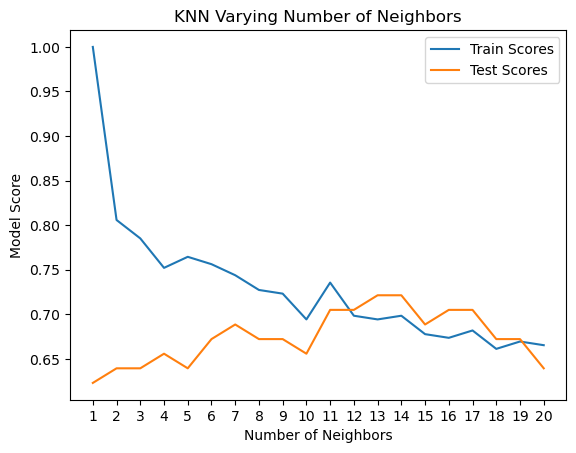

In [166]:
plt.plot(neighbors, train_scores, label="Train Scores")
plt.plot(neighbors, test_scores, label="Test Scores")
plt.xticks(neighbors)
plt.xlabel("Number of Neighbors")
plt.ylabel("Model Score")
plt.legend()
plt.title("KNN Varying Number of Neighbors");


## Hyperparameter tuning with RandomizedSearchCV

We're going to tune:
* LogisticRegression()
* RandomForestClassifier()

... using RandomizedSearchCV

In [178]:
# Hyperparameter grid for Logistic Regression
log_reg_grid = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear"]
}

# Hyperparameter grid for Random Forest
rf_grid = {
    "n_estimators": np.arange(10, 1000, 50),
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2)
}


In [180]:
# Tune logistic regression
np.random.seed(42)

# Setup random hyperparameter search for Logistic Regression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)

# Fit random hyperparameter search model for Logistic Regression
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [182]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': 206.913808111479}

In [183]:
rs_log_reg.score(X_test, y_test)

0.8360655737704918

In [185]:
# Setup random hyperparameter search for Random Forest
np.random.seed(42)

#setup random hyperparameter search for Random Forest
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                            param_distributions=rf_grid,
                            cv=5,
                            n_iter=20,
                            verbose=True)

# Fit random hyperparameter search model for Random Forest
rs_rf.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [186]:
# Find the best parameters
rs_rf.best_params_

{'n_estimators': 310,
 'min_samples_split': 2,
 'min_samples_leaf': 19,
 'max_depth': 5}

In [187]:
# Evaluate the Randomized search Random Forest model
rs_rf.score(X_test, y_test)

0.8688524590163934

## Hyperparamter Tuning with GridSearchCV

Since our LogisticRegression model provides the best scores so far, we'll try and improve them again using GridSearchCV...

In [190]:
# Different hyperparameter for our logistic regression model
log_reg_grid = {"C": np.logspace(-4, 4, 30),
                "solver": ["liblinear"],
                "penalty": ["l1", "l2"]}

# Setup grid huperparameter search for Logistic Regression
gs_log_reg = GridSearchCV(LogisticRegression(),
                            param_grid=log_reg_grid,
                            cv=5,
                            verbose=True)
# Fit grid hyperparameter search model for Logistic Regression
gs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             verbose=True)

In [191]:
# let's check the best hyperparameters
gs_log_reg.best_params_

{'C': 32.90344562312671, 'penalty': 'l1', 'solver': 'liblinear'}

In [192]:
# Evaluate the grid search Logistic Regression model
gs_log_reg.score(X_test, y_test)

0.8360655737704918

## Evaluting our tuned machine learning classifier, beyond accuracy

* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* F1-score

... and it would be great if cross-validation was used where possible.

To make comparisons and evaluate our trained model, first we need to make predictions.

In [193]:
# Make prediction with tuned model
y_preds = gs_log_reg.predict(X_test)

y_preds 

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [194]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

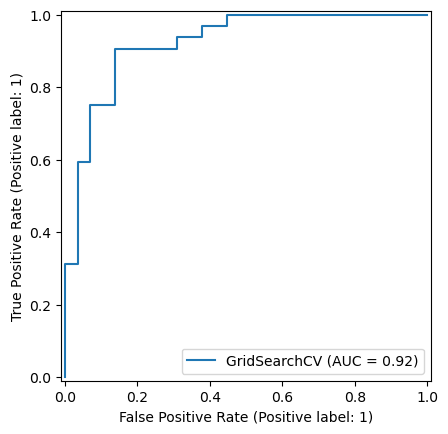

In [201]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test)
plt.show()


In [202]:
# Confusion matrix
print(confusion_matrix(y_test, y_preds))

[[25  4]
 [ 6 26]]


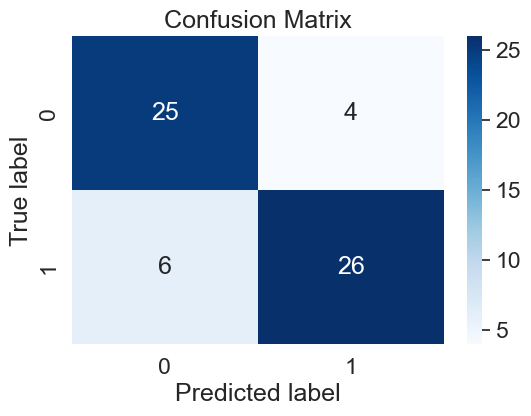

In [203]:
sns.set(font_scale=1.5)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()



Now we've got a ROC curve, an AUC metric and a confusion matrix, let's get a classification report as well as cross-validated precision, recall and f1-score.

In [204]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83        29
           1       0.87      0.81      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



### Calculate evaluation metrics using cross-validation

We're going to calculate accuracy, precision, recall and f1-score of our model using cross-validation and to do so we'll be using `cross_val_score()`.

In [205]:
# check best hyperparameter 
gs_log_reg.best_params_

{'C': 32.90344562312671, 'penalty': 'l1', 'solver': 'liblinear'}

In [216]:
# Create a new classifier with best parameters
clf = LogisticRegression(C=0.20433597178569418,
                           solver="liblinear",
                           penalty="l1")


In [217]:
# Cross -validated accuracy
from sklearn.model_selection import cross_val_score


cv_acc = cross_val_score(clf,
                         X,
                         y,
                         cv=5,
                         scoring="accuracy")
cv_acc

array([0.80327869, 0.8852459 , 0.86885246, 0.9       , 0.75      ])

In [218]:
cv_acc = np.mean(cv_acc)
cv_acc

0.8414754098360655

In [219]:
# Cross-validated precision
cv_precision = cross_val_score(clf,
                                 X,
                                 y,
                                 cv=5,
                                 scoring="precision")
cv_precision = np.mean(cv_precision)
cv_precision

0.8157788007788007

In [220]:
# Cross validated recall
cv_recall = cross_val_score(clf,
                              X,
                              y,
                              cv=5,
                              scoring="recall")
cv_recall = np.mean(cv_recall)
cv_recall

0.9212121212121213

In [221]:
# Cross validated  f1-score
cv_f1 = cross_val_score(clf,
                          X,
                          y,
                          cv=5,
                          scoring="f1")
cv_f1 = np.mean(cv_f1)
cv_f1

0.8647767195025716

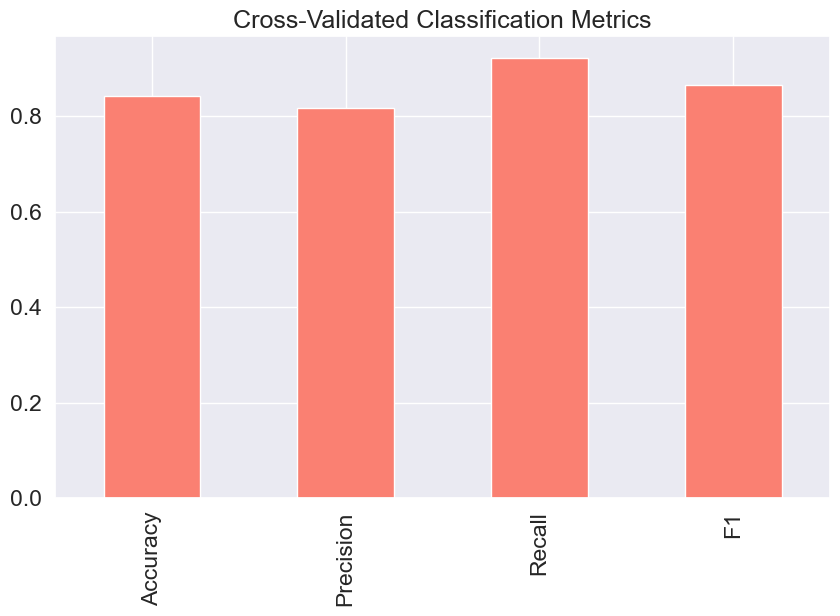

In [215]:
# Visualize cross-validated metrics
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                            "Precision": cv_precision,
                            "Recall": cv_recall,
                            "F1": cv_f1},
                            index=[0])
cv_metrics.T.plot.bar(title="Cross-Validated Classification Metrics",
                      legend=False,
                      color=["salmon", "lightblue", "lightgreen", "orange"],
                      figsize=(10, 6));

### Feature Importance

Feature importance is another as asking, "which features contributed most to the outcomes of the model and how did they contribute?"

Finding feature importance is different for each machine learning model. One way to find feature importance is to search for "(MODEL NAME) feature importance".

Let's find the feature importance for our LogisticRegression model...

In [222]:
# Fit an instance of logistic regression
clf = LogisticRegression(C=0.20433597178569418,
                           solver="liblinear",
                           penalty="l1")   
clf.fit(X_train, y_train);

In [223]:
# Check coef_
clf.coef_

array([[ 0.        , -0.78122881,  0.60978594, -0.01046467, -0.00183679,
         0.        ,  0.        ,  0.02533329, -0.35453824, -0.55353633,
         0.26044184, -0.55933243, -0.53936893]])

In [ ]:
# Match coef of features to columns
#This line of code is creating a dictionary called `feature_dict` where the 
# keys are the column names of a DataFrame `df` and the values are the coefficients
#  of the features from a trained classifier `clf`. It achieves this by 
# zipping together the column names with the coefficients and converting
#  them into a dictionary.
feature_dict = dict(zip(df.columns, list(clf.coef_[0])))
feature_dict


{'age': 0.0,
 'sex': -0.7812288098022556,
 'cp': 0.6097859393528886,
 'trestbps': -0.010464665915138144,
 'chol': -0.0018367919965592686,
 'fbs': 0.0,
 'restecg': 0.0,
 'thalach': 0.025333285942143513,
 'exang': -0.3545382364599866,
 'oldpeak': -0.5535363266503235,
 'slope': 0.26044183656415704,
 'ca': -0.5593324305777687,
 'thal': -0.539368930498295}

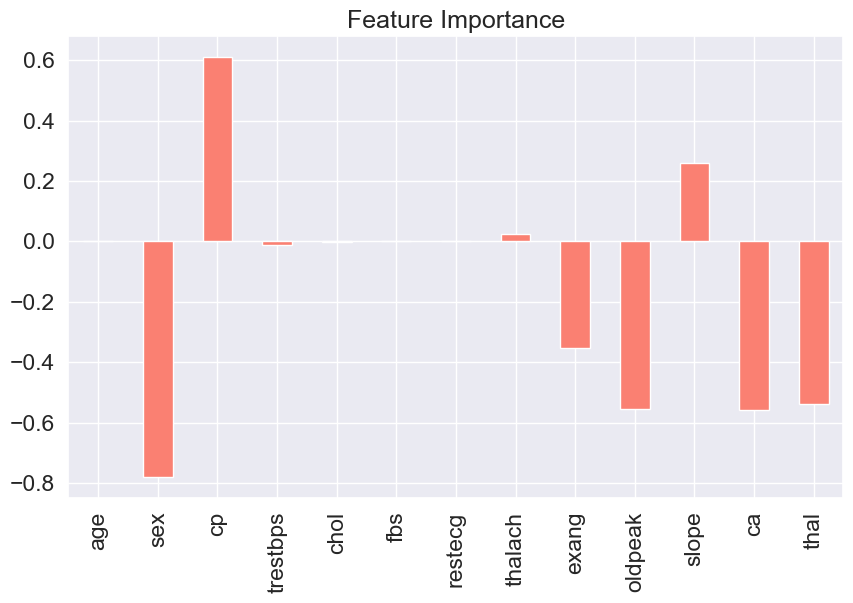

In [227]:
# Visualize the feature importance
feature_df = pd.DataFrame(feature_dict, index=[0])
feature_df.T.plot(title="Feature Importance",
                   legend=False,
                   kind="bar",
                   color=["salmon"],
                   figsize=(10, 6));


In [234]:
pd.crosstab(df["sex"], df["target"])


target,0,1
sex,,
0,24,72
1,114,93


In [235]:
pd.crosstab(df["slope"], df["target"])

target,0,1
slope,,
0,12,9
1,91,49
2,35,107


slope - the slope of the peak exercise ST segment
* 0: Upsloping: better heart rate with excercise (uncommon)
* 1: Flatsloping: minimal change (typical healthy heart)
* 2: Downslopins: signs of unhealthy heart

## 6. Experimentation

If you haven't hit your evaluation metric yet... ask yourself...

* Could you collect more data?
* Could you try a better model? Like CatBoost or XGBoost?
* Could you improve the current models? (beyond what we've done so far)
* If your model is good enough (you have hit your evaluation metric) how would you export it and share it with others?